In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import Holt
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [3]:
df = pd.read_csv(r'airline_passengers.csv', index_col = 'Month', parse_dates = True)

In [4]:
holt = Holt(df['Passengers']
            # , initialization_method = 'legacy-heuristic' #use this for previous version of the class
           )

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [5]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [6]:
df.index.freq = 'MS'

In [7]:
holt = Holt(df['Passengers']
            # , initialization_method = 'legacy-heuristic' #use this for previous version of the class
           )

In [8]:
res_h = holt.fit()

In [12]:
res_h

In [11]:
res_h.params

{'smoothing_level': np.float64(0.995),
 'smoothing_trend': np.float64(0.0001),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(112.0),
 'initial_trend': np.float64(6.0),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [13]:
""" res_h doesnt have seasonality component hence the above paramaters for seasonal are nulls.
level alpha close to 1 meaning heavily biased towards last actual value itself
trend beta close to 0 meaning very less weightage to the latest slope but heavy or almost all weightage to previous slope"""

' res_h doesnt have seasonality component hence the above paramaters for seasonal are nulls.\nlevel alpha close to 1 meaning heavily biased towards last actual value itself\ntrend beta close to 0 meaning very less weightage to the latest slope but heavy or almost all weightage to previous slope'

In [14]:
df['Holt'] = res_h.fittedvalues

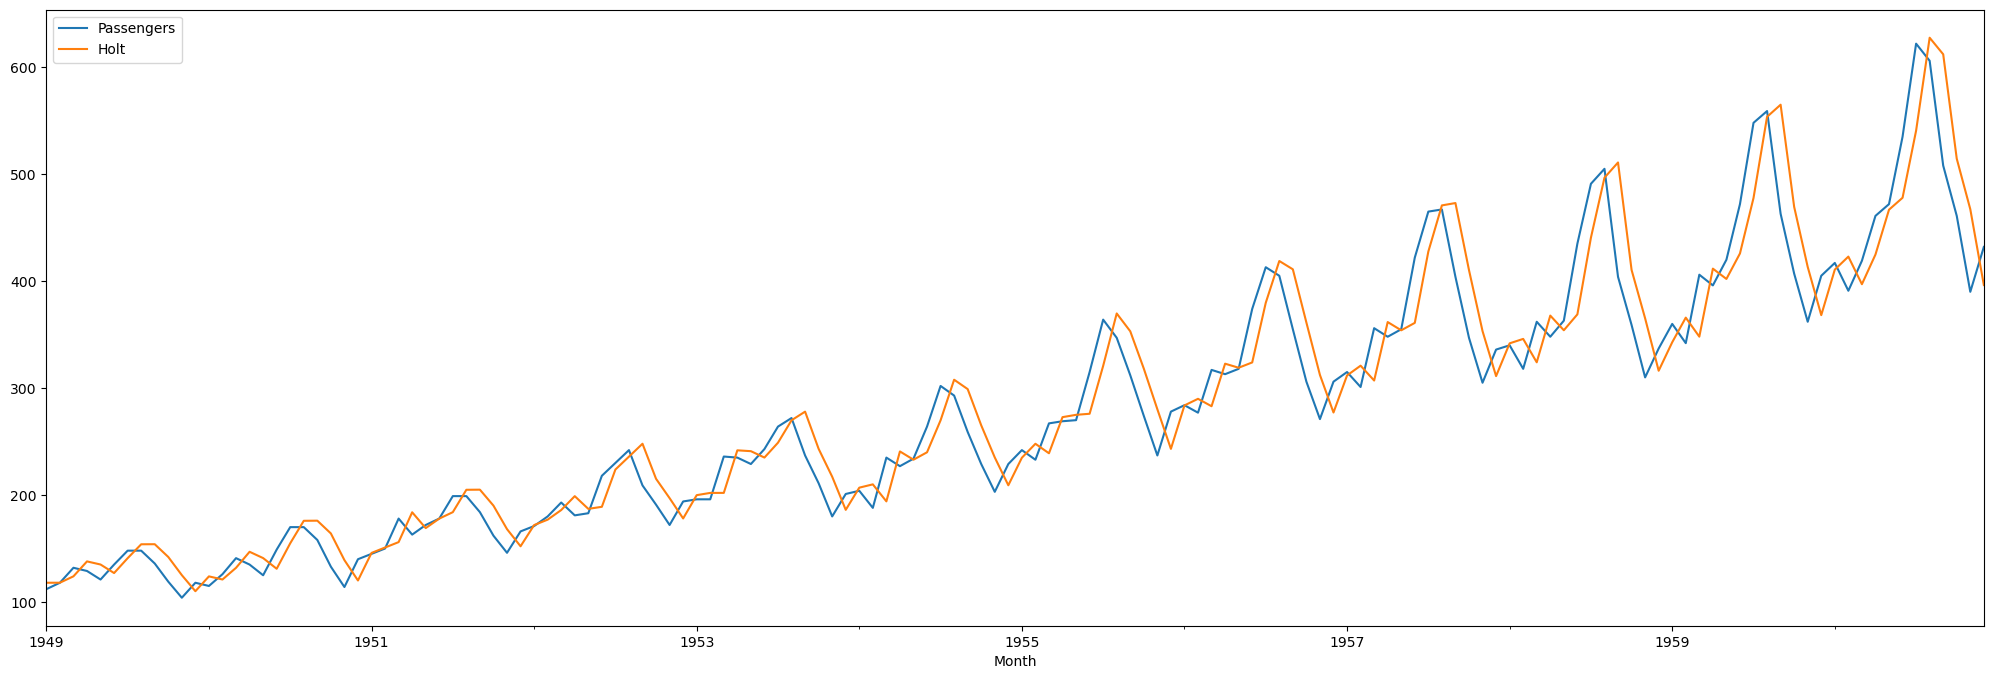

In [15]:
df[['Passengers','Holt']].plot(figsize = (25,8));

In [16]:
""" this is very similar to naive forecasting which is simply copying the previous values which is what Simple Exp Smoothing was also doing 
with the same data"""

' this is very similar to naive forecasting which is simply copying the previous values which is what Simple Exp Smoothing was also doing \nwith the same data'

In [19]:
df.tail(n=20)

,Passengers,Holt
Month,,
1959-05-01,420,402.032627
1959-06-01,472,425.866247
1959-07-01,548,477.730005
1959-08-01,559,553.616316
1959-09-01,463,564.941283
1959-10-01,407,469.467765
1959-11-01,362,413.264181
1959-12-01,405,368.203063
1960-01-01,417,410.766418


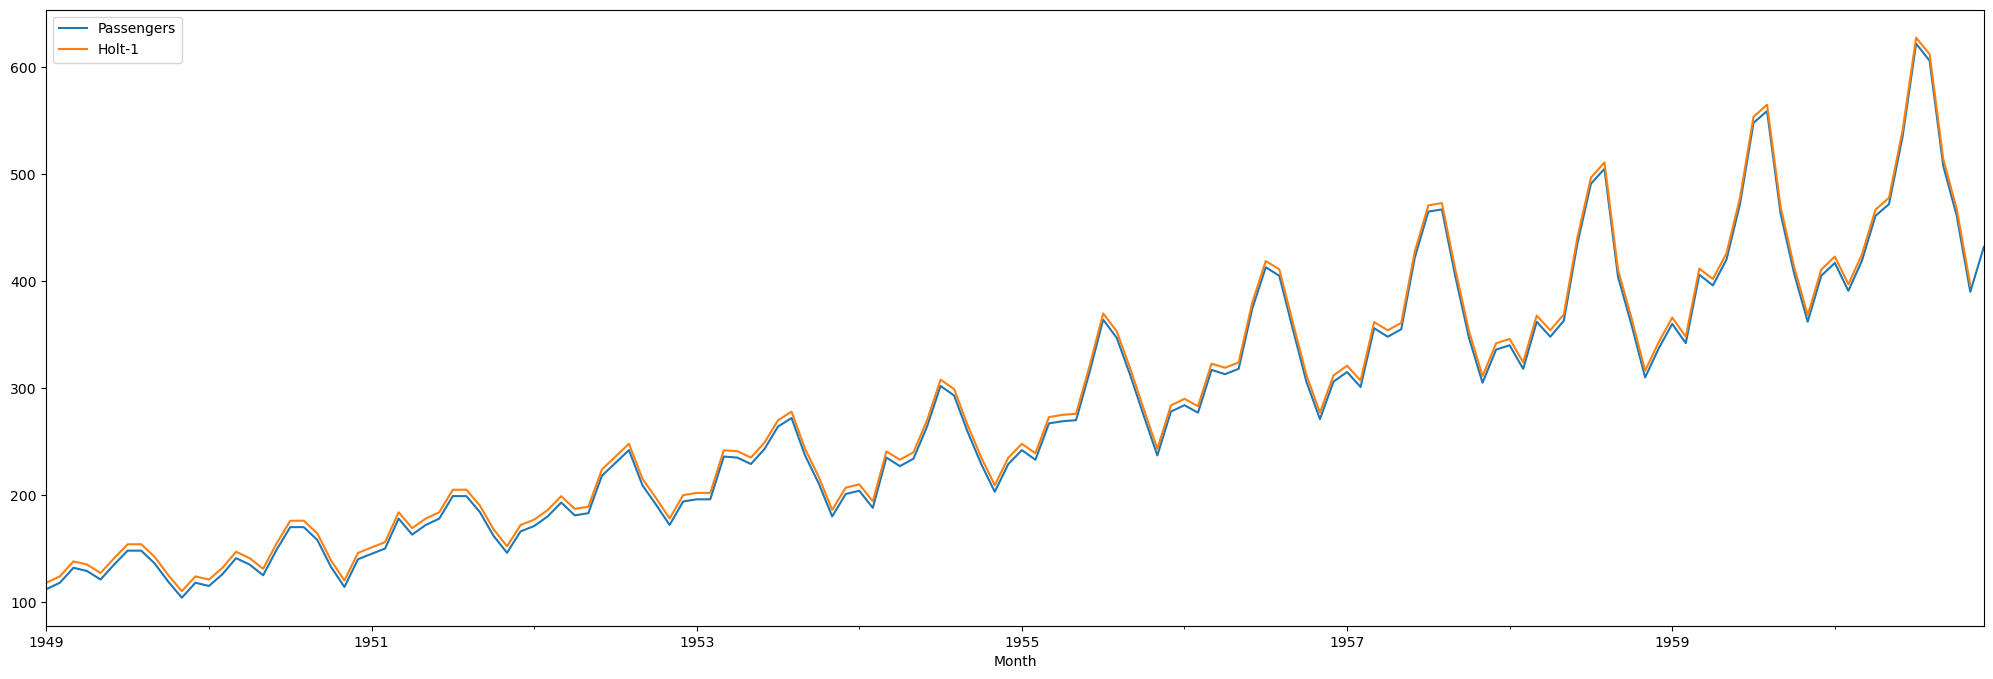

In [21]:
### you should NOT shift the values back to make it overlap to the previous data point
### remember we are predicting the values - the lagged data suggests that it is learning from the past data which has actually happenned
## hence the lag from the last value # shifting the values doesnt make sense
df['Holt-1'] = df['Holt'].shift(-1)
df[['Passengers','Holt-1']].plot(figsize = (25,8));

In [22]:
df.tail()

,Passengers,Holt,Holt-1
Month,,,
1960-08-01,606,627.561287,612.073575
1960-09-01,508,612.073575,514.475781
1960-10-01,461,514.475781,467.217472
1960-11-01,390,467.217472,396.328497
1960-12-01,432,396.328497,NaN


# forecasting using Holt Linear
### splitting data into train and test

In [24]:
Ntest = 12 
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [25]:
train_idx = df.index <= train.index[-1] 
test_idx = df.index > train.index[-1]
train_idx

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [27]:
holt = Holt(train['Passengers']
            # , initialization_method ='legacy-heuristic'
           )
res_h = holt.fit()
df.loc[train_idx, 'Holt'] = res_h.fittedvalues
df.loc[test_idx,'Holt'] = res_h.forecast(Ntest)

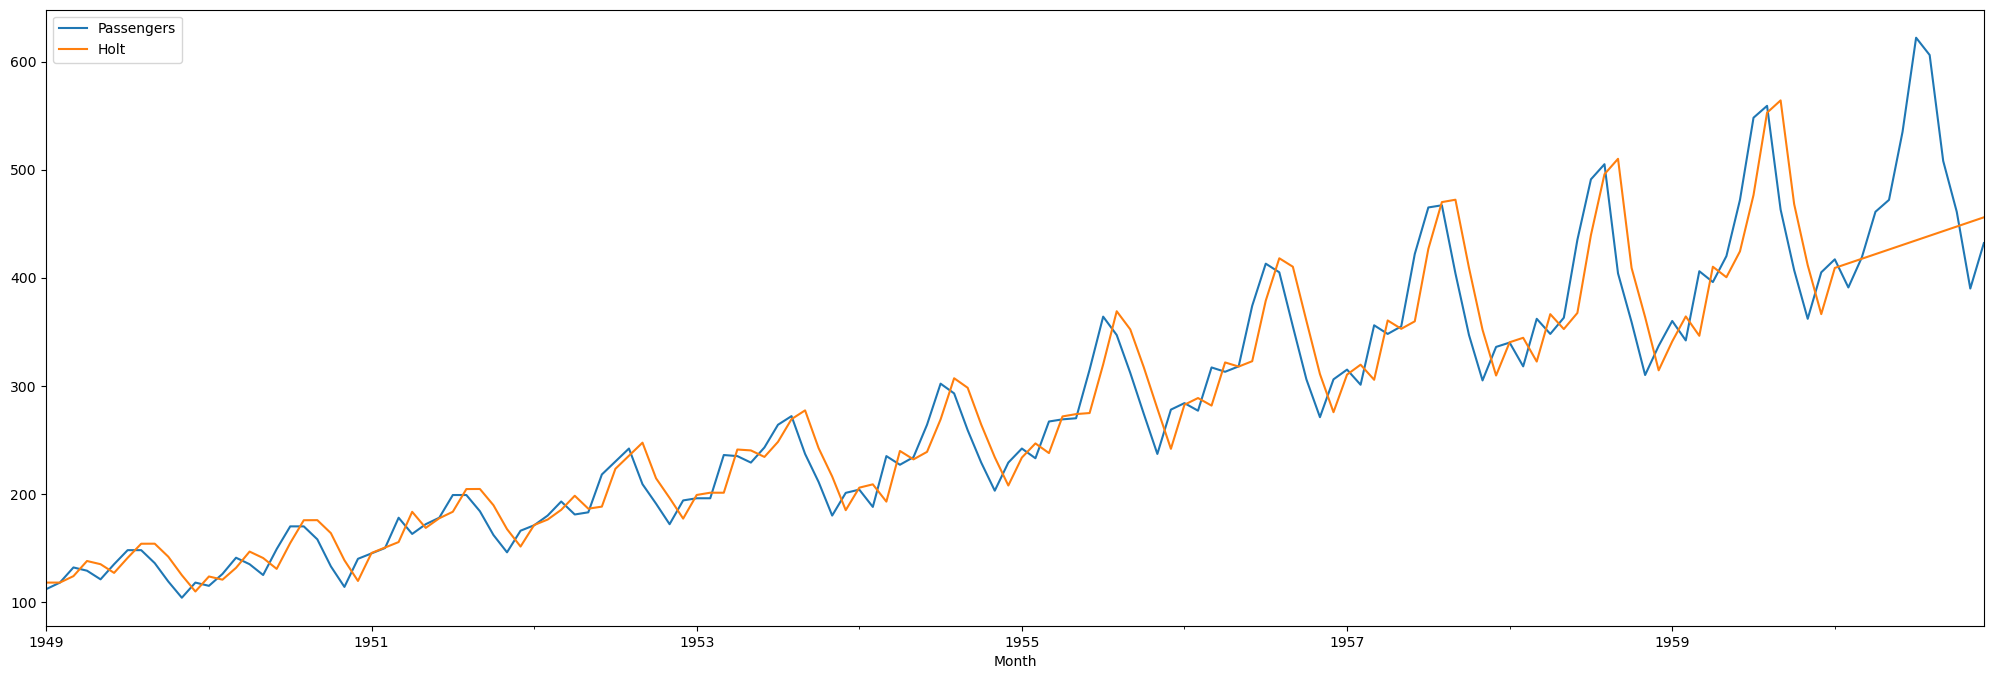

In [28]:
df[['Passengers','Holt']].plot(figsize = (25,8));

In [29]:
""" as seen in the graph looking at the straight line above, it clearly shows that there is no seasonality component above"""

' as seen in the graph looking at the straight line above, it clearly shows that there is no seasonality component above'

In [33]:
print("Test data starts from ", test.index[0])
df.tail(20)

Test data starts from  1960-01-01 00:00:00


,Passengers,Holt,Holt-1
Month,,,
1959-05-01,420,400.453758,425.866247
1959-06-01,472,424.376232,477.730005
1959-07-01,548,476.456240,553.616316
1959-08-01,559,552.667316,564.941283
1959-09-01,463,564.021106,469.467765
1959-10-01,407,468.089276,413.264181
1959-11-01,362,411.608638,368.203063
1959-12-01,405,366.322583,410.766418
1960-01-01,417,409.061638,422.919855


In [34]:
res_h.params

{'smoothing_level': np.float64(0.9950228030468105),
 'smoothing_trend': np.float64(0.004637470054154064),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(112.0),
 'initial_trend': np.float64(6.0),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [35]:
df.head()

,Passengers,Holt,Holt-1
Month,,,
1949-01-01,112,118.000000,118.029403
1949-02-01,118,118.002177,123.999547
1949-03-01,132,123.972314,137.960194
1949-04-01,129,137.969391,135.044106
1949-05-01,121,135.012601,127.068128
